# TESS Light Curve Inspector
Visually inspect PDC-SAP light curves per sector for any priority planet.

**Workflow:**
1. Run **Cell 1** (setup) once
2. Run **Cell 2** — pick a planet from the dropdown, click **Load**
3. Run **Cell 3** — sector grid overview (all sectors, transit markers)
4. Run **Cell 4** — zoom into a single sector

In [ ]:
# Cell 1 — Setup
import warnings
warnings.filterwarnings('ignore')

import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import lightkurve as lk
from ipywidgets import interact, interactive, widgets, HBox, VBox
from IPython.display import display, clear_output

BJD_OFFSET   = 2457000.0
MJD_TO_BTJD  = 2400000.5 - BJD_OFFSET

# Load catalogs
df_priority = pd.read_csv('planets_priority.csv')
df_priority['t0_btjd'] = df_priority['pl_tranmid'] - BJD_OFFSET

try:
    df_lookup = pd.read_csv('sector_lookup.csv')
    lookup_host = dict(zip(df_lookup['System'], df_lookup['host_star']))
except FileNotFoundError:
    lookup_host = {}

def get_host(system_name):
    host = lookup_host.get(system_name,
           df_priority[df_priority['System']==system_name]['host_star'].values[0])
    return re.sub(r'\s+[A-D]$', '', str(host)).strip()

def get_planet_row(system_name):
    return df_priority[df_priority['System']==system_name].iloc[0]

def get_sector_time_ranges(host_star):
    """Returns {sector: (t_min_btjd, t_max_btjd)} — SPOC 2-min only."""
    results = lk.search_lightcurve(host_star, mission='TESS', exptime=120, author='SPOC')
    if results is None or len(results) == 0:
        return {}
    table = results.table
    ranges = {}
    for row in table:
        sec  = int(row['sequence_number'])
        tmin = float(row['t_min']) + MJD_TO_BTJD
        tmax = float(row['t_max']) + MJD_TO_BTJD
        if sec not in ranges:
            ranges[sec] = [tmin, tmax]
        else:
            ranges[sec][0] = min(ranges[sec][0], tmin)
            ranges[sec][1] = max(ranges[sec][1], tmax)
    return {s: tuple(v) for s, v in ranges.items()}

def predict_transit_times(period, t0, t_min, t_max):
    n_lo = int(np.ceil((t_min - t0) / period))
    n_hi = int(np.floor((t_max - t0) / period))
    return t0 + np.arange(n_lo, n_hi + 1) * period

# Global state — stores the loaded light curve and sector info
STATE = {}

print('Setup complete. Run Cell 2 to load a planet.')

In [ ]:
# Cell 2 — Planet selector + loader (SPOC PDC-SAP 2-min cadence only)
planet_list = sorted(df_priority['System'].tolist())

planet_dd  = widgets.Dropdown(options=planet_list, value=planet_list[0],
                               description='Planet:', layout=widgets.Layout(width='280px'))
load_btn   = widgets.Button(description='Load Light Curve',
                             button_style='primary', layout=widgets.Layout(width='180px'))
status_out = widgets.Output()

def on_load(b):
    with status_out:
        clear_output()
        name    = planet_dd.value
        host    = get_host(name)
        row     = get_planet_row(name)
        period  = float(row['Period'])
        t0      = float(row['t0_btjd'])
        trandur = float(row['pl_trandur'])

        print(f'Loading {name} (host: {host})')
        print(f'  Period={period:.6f}d  t0(BTJD)={t0:.4f}  dur={trandur:.2f}h')

        print('  Fetching sector time ranges (SPOC 2-min)...')
        sector_ranges = get_sector_time_ranges(host)
        print(f'  Sectors: {sorted(sector_ranges.keys())}')

        print('  Downloading SPOC PDC-SAP 2-min light curves...')
        results = lk.search_lightcurve(host, mission='TESS', exptime=120, author='SPOC')
        collection = results.download_all(quality_bitmask='default',
                                          flux_column='pdcsap_flux')

        def robust_normalize(lc):
            # Strip units and normalize by 75th percentile
            flux_vals = np.array(lc.flux.value, dtype=float)
            p75 = np.nanpercentile(flux_vals, 75)
            divisor = p75 if abs(p75) > 1e-10 else (float(np.nanmedian(flux_vals)) or 1.0)
            return lk.LightCurve(time=lc.time, flux=flux_vals / divisor)

        lc_full = collection.stitch(corrector_func=robust_normalize)
        lc_full = lc_full.remove_nans()
        lc_full = lc_full.remove_outliers(sigma_lower=1e6, sigma_upper=4.0)

        flux_median = float(np.nanmedian(lc_full.flux.value))
        flux_min    = float(np.nanmin(lc_full.flux.value))
        flux_max    = float(np.nanmax(lc_full.flux.value))
        print(f'  Flux check: median={flux_median:.4f}  min={flux_min:.4f}  max={flux_max:.4f}')

        if not (0.5 < flux_median < 2.0):
            print(f'  Warning: re-normalizing (median={flux_median:.3f})')
            lc_full = lc_full / flux_median

        time = lc_full.time.value
        flux = lc_full.flux.value

        print('  Refining t0 via phase fold...')
        try:
            lc_fold  = lc_full.fold(period=period, epoch_time=t0, normalize_phase=True)
            binned   = lc_fold.bin(n_bins=300)
            ph       = binned.phase.value
            fl       = binned.flux.value
            valid    = np.isfinite(fl)
            phase_offset = float(ph[valid][np.nanargmin(fl[valid])])
            t0_shift     = phase_offset * period
            t0_refined   = t0 + t0_shift
            print(f'  Phase offset: {phase_offset:.4f} ({t0_shift*24*60:+.1f} min)')
            print(f'  t0: {t0:.6f} → {t0_refined:.6f} BTJD')
            t0 = t0_refined
        except Exception as e:
            print(f'  t0 refinement failed ({e}) — using catalog t0')

        sector_lcs = {}
        for sec, (smin, smax) in sector_ranges.items():
            mask = (time >= smin) & (time <= smax)
            if mask.sum() > 0:
                sector_lcs[sec] = (time[mask], flux[mask])

        STATE.update({
            'name':          name,
            'host':          host,
            'period':        period,
            't0':            t0,
            'trandur':       trandur,
            'sector_ranges': sector_ranges,
            'sector_lcs':    sector_lcs,
            'time':          time,
            'flux':          flux,
        })

        print(f'  Done. {len(sector_lcs)} sectors, {len(time):,} points.')
        print(f'\nReady — run Cells 3 / 4 / 5.')

load_btn.on_click(on_load)
display(VBox([HBox([planet_dd, load_btn]), status_out]))

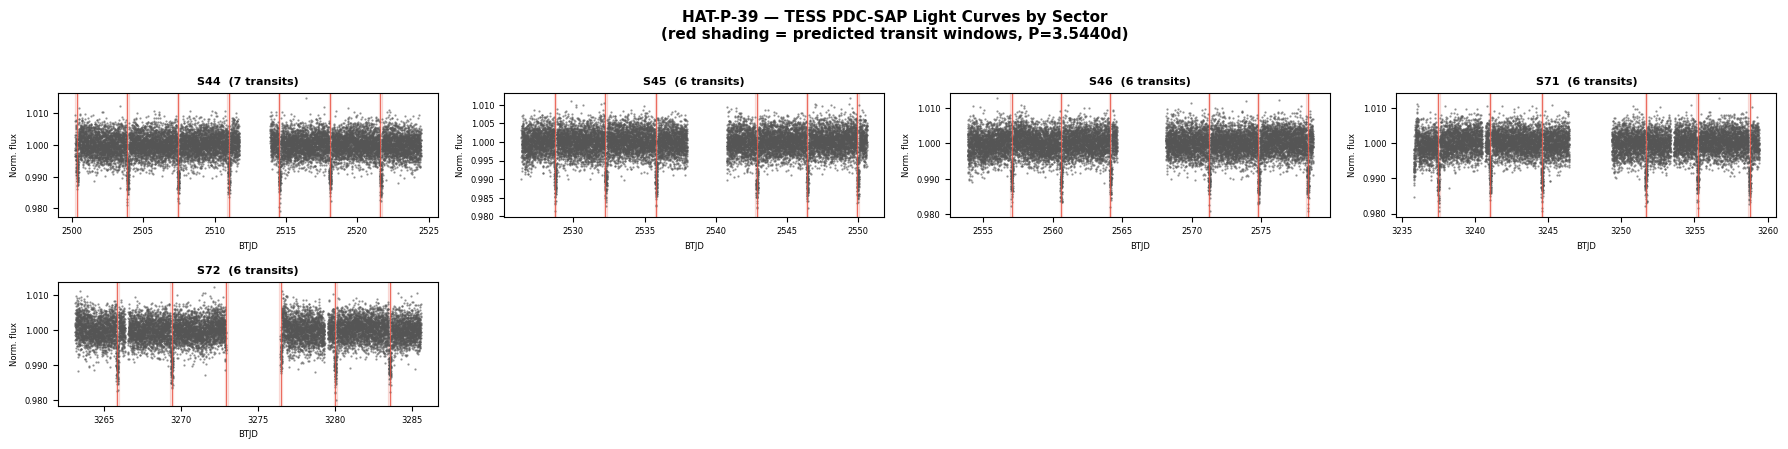

Saved: HAT-P-39_sector_grid.png


In [9]:
# Cell 3 — Sector grid overview
# Shows all sectors in a multi-panel grid with transit markers

if not STATE:
    print('Run Cell 2 first to load a planet.')
else:
    name       = STATE['name']
    period     = STATE['period']
    t0         = STATE['t0']
    trandur    = STATE['trandur']
    sector_lcs = STATE['sector_lcs']

    sectors = sorted(sector_lcs.keys())
    n       = len(sectors)
    ncols   = 4
    nrows   = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 4.5, nrows * 2.2),
                              sharey=False)
    axes = np.array(axes).flatten()

    half_dur = trandur / 24 / 2  # in days

    for i, sec in enumerate(sectors):
        ax = axes[i]
        t, f = sector_lcs[sec]

        # Light curve
        ax.plot(t, f, '.', ms=1.2, color='#555555', alpha=0.6, rasterized=True)

        # Predicted transit times
        transits = predict_transit_times(period, t0, t.min(), t.max())
        n_transits = 0
        for tc in transits:
            in_win = np.abs(t - tc) <= half_dur
            if in_win.sum() >= 5:
                ax.axvspan(tc - half_dur, tc + half_dur,
                           alpha=0.15, color='#E74C3C', zorder=0)
                ax.axvline(tc, color='#E74C3C', lw=0.7, alpha=0.8)
                n_transits += 1

        ax.set_title(f'S{sec:02d}  ({n_transits} transits)', fontsize=8, fontweight='bold')
        ax.set_xlabel('BTJD', fontsize=6)
        ax.set_ylabel('Norm. flux', fontsize=6)
        ax.tick_params(labelsize=6)
        ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))

    # Hide unused panels
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{name} — TESS PDC-SAP Light Curves by Sector\n'
                 f'(red shading = predicted transit windows, P={period:.4f}d)',
                 fontsize=11, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{name}_sector_grid.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {name}_sector_grid.png')

In [10]:
# Cell 4 — Single sector zoom + auto/manual t0 alignment
# Safe to re-run: widgets are created once and reused.

if not STATE:
    print('Run Cell 2 first.')
else:
    from scipy.optimize import minimize_scalar
    from IPython.display import display as ipy_display

    sector_lcs = STATE['sector_lcs']
    sectors    = sorted(sector_lcs.keys())

    def auto_align_t0(t, f, usable_tc, half_dur):
        phase_all, flux_all = [], []
        for tc in usable_tc:
            mask = np.abs(t - tc) <= half_dur
            if mask.sum() >= 5:
                phase_all.extend((t[mask] - tc).tolist())
                flux_all.extend(f[mask].tolist())
        if len(phase_all) < 10:
            return 0.0
        ph, fl = np.array(phase_all), np.array(flux_all)
        edges = np.linspace(-half_dur, half_dur, 41)
        bc, bf = [], []
        for i in range(40):
            m = (ph >= edges[i]) & (ph < edges[i+1])
            if m.sum() >= 2:
                bc.append(0.5*(edges[i]+edges[i+1]))
                bf.append(np.median(fl[m]))
        if len(bc) < 5:
            return 0.0
        bc, bf = np.array(bc), np.array(bf)
        mi = np.argmin(bf)
        lo, hi = max(0, mi-5), min(len(bc), mi+6)
        c = np.polyfit(bc[lo:hi], bf[lo:hi], 2)
        return float(-c[1]/(2*c[0])) if abs(c[0]) > 1e-12 else float(bc[mi])

    # ── Create widgets once, reuse on re-run ─────────────────────────────────
    if 'w4' not in STATE:
        STATE['w4'] = {
            'sec':    widgets.Dropdown(description='Sector:',
                                       layout=widgets.Layout(width='200px')),
            'toggle': widgets.ToggleButton(value=True,
                                           description='Auto-align ON',
                                           button_style='success',
                                           layout=widgets.Layout(width='150px')),
            'slider': widgets.FloatSlider(value=0.0, min=-0.5, max=0.5, step=0.001,
                                          description='t0 offset (d):',
                                          readout_format='.3f', disabled=True,
                                          style={'description_width': '120px'},
                                          layout=widgets.Layout(width='480px')),
            'info':   widgets.Label(value=''),
            'out':    widgets.Output(),
        }
        w = STATE['w4']
        w['sec'].options = sectors
        w['sec'].value   = sectors[0]

        def on_toggle(change):
            w['slider'].disabled   = w['toggle'].value
            w['toggle'].description = 'Auto-align ON' if w['toggle'].value else 'Auto-align OFF'
            w['toggle'].button_style = 'success' if w['toggle'].value else 'warning'
            redraw4()

        def redraw4(change=None):
            with w['out']:
                clear_output(wait=True)
                sector   = w['sec'].value
                t0_base  = STATE['t0']
                period   = STATE['period']
                trandur  = STATE['trandur']
                name     = STATE['name']
                t, f     = sector_lcs[sector]
                half_dur = trandur / 24 / 2

                transits = predict_transit_times(period, t0_base, t.min(), t.max())
                usable   = [tc for tc in transits
                            if np.abs(t - tc).min() <= half_dur
                            and np.sum(np.abs(t - tc) <= half_dur) >= 5]

                if w['toggle'].value and usable:
                    offset = auto_align_t0(t, f, usable, half_dur)
                    w['info'].value = (f'Auto offset: {offset:+.4f} d  '
                                       f'({offset*24*60:+.1f} min)  '
                                       f'→ STATE["t0"] += {offset:.6f}')
                else:
                    offset = w['slider'].value
                    w['info'].value = f'Manual offset: {offset:+.4f} d'

                t0 = t0_base + offset
                transits = predict_transit_times(period, t0, t.min(), t.max())
                usable   = [tc for tc in transits
                            if np.abs(t - tc).min() <= half_dur
                            and np.sum(np.abs(t - tc) <= half_dur) >= 5]

                fig, ax = plt.subplots(figsize=(14, 4))
                ax.plot(t, f, '.', ms=1.5, color='#333333', alpha=0.7,
                        rasterized=True, label='PDC-SAP flux')
                for k, tc in enumerate(usable):
                    ax.axvspan(tc - half_dur, tc + half_dur, alpha=0.18,
                               color='#E74C3C', zorder=0,
                               label='Transit window' if k == 0 else '')
                    ax.axvline(tc, color='#E74C3C', lw=1.0, alpha=0.9)
                    ax.text(tc, f.min(), f'T{k+1}', fontsize=6,
                            ha='center', va='bottom', color='#C0392B')
                ax.set_xlabel('BTJD (days)', fontsize=10)
                ax.set_ylabel('Normalised Flux', fontsize=10)
                ax.set_title(f'{name} — Sector {sector:02d}  '
                             f'({len(usable)} transits | P={period:.4f}d | '
                             f'dur={trandur:.2f}h | offset={offset:+.4f}d)',
                             fontsize=10, fontweight='bold')
                ax.legend(fontsize=8, markerscale=4)
                ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
                plt.tight_layout()
                ipy_display(fig)
                plt.close(fig)

        STATE['redraw4'] = redraw4
        w['sec'].observe(redraw4, names='value')
        w['slider'].observe(redraw4, names='value')
        w['toggle'].observe(on_toggle, names='value')
        display(HBox([w['sec'], w['toggle']]), w['slider'], w['info'], w['out'])
        redraw4()

    else:
        # Already displayed — just update sector options and redraw
        w = STATE['w4']
        w['sec'].options = sectors
        if w['sec'].value not in sectors:
            w['sec'].value = sectors[0]
        STATE['redraw4']()

FloatSlider(value=0.0, description='t0 offset (d):', disabled=True, layout=Layout(width='480px'), max=0.5, min…

Label(value='')

Output()

In [11]:
# Cell 5 — Individual transit zoom
# Safe to re-run: widgets are created once and reused.

if not STATE:
    print('Run Cell 2 first.')
else:
    from IPython.display import display as ipy_display

    sector_lcs = STATE['sector_lcs']
    sectors    = sorted(sector_lcs.keys())

    if 'w5' not in STATE:
        STATE['w5'] = {
            'sec':    widgets.Dropdown(description='Sector:',
                                       layout=widgets.Layout(width='200px')),
            'slider': widgets.IntSlider(value=1, min=1, max=30, step=1,
                                        description='Transit #:',
                                        layout=widgets.Layout(width='350px')),
            'info':   widgets.Label(value=''),
            'out':    widgets.Output(),
        }
        w = STATE['w5']
        w['sec'].options = sectors
        w['sec'].value   = sectors[0]

        def redraw5(change=None):
            with w['out']:
                clear_output(wait=True)
                sector    = w['sec'].value
                transit_n = w['slider'].value
                name      = STATE['name']
                period    = STATE['period']
                t0        = STATE['t0']
                trandur   = STATE['trandur']
                t, f      = sector_lcs[sector]
                half_dur  = trandur / 24 / 2

                transits = predict_transit_times(period, t0, t.min(), t.max())
                usable   = [tc for tc in transits
                            if np.sum(np.abs(t - tc) <= half_dur) >= 5]

                if not usable:
                    w['info'].value = f'No usable transits in Sector {sector}.'
                    return

                n_use = len(usable)
                w['info'].value = f'Sector {sector}: {n_use} usable transits'

                # Update slider max safely
                if w['slider'].max != n_use:
                    w['slider'].unobserve(redraw5, names='value')
                    w['slider'].max = n_use
                    w['slider'].observe(redraw5, names='value')

                idx  = min(transit_n, n_use) - 1
                tc   = usable[idx]
                mask = np.abs(t - tc) <= half_dur * 3

                if mask.sum() == 0:
                    w['info'].value = 'No data in window.'
                    return

                fig, ax = plt.subplots(figsize=(10, 4))
                ax.plot(t[mask], f[mask], 'o', ms=3, color='#2C3E50',
                        alpha=0.8, label='PDC-SAP')
                ax.axvspan(tc - half_dur, tc + half_dur,
                           alpha=0.15, color='#E74C3C', label='Transit window')
                ax.axvline(tc, color='#E74C3C', lw=1.2, ls='--', label='Predicted t0')
                ax.axhline(1.0, color='grey', lw=0.8, ls=':', alpha=0.5)
                ax.set_xlabel('BTJD (days)', fontsize=10)
                ax.set_ylabel('Normalised Flux', fontsize=10)
                ax.set_title(f'{name}  Sector {sector:02d}  Transit {idx+1}/{n_use}\n'
                             f't0={tc:.5f} BTJD  |  P={period:.4f}d  dur={trandur:.2f}h',
                             fontsize=10, fontweight='bold')
                ax.legend(fontsize=8)
                ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
                plt.tight_layout()
                ipy_display(fig)
                plt.close(fig)

        STATE['redraw5'] = redraw5
        w['sec'].observe(redraw5, names='value')
        w['slider'].observe(redraw5, names='value')
        display(HBox([w['sec'], w['slider']]), w['info'], w['out'])
        redraw5()

    else:
        # Already displayed — just update options and redraw
        w = STATE['w5']
        w['sec'].options = sectors
        if w['sec'].value not in sectors:
            w['sec'].value = sectors[0]
        STATE['redraw5']()

Label(value='')

Output()

---
## Cell 6 — Master Batman Fit
Phase-folds all available data for the loaded planet and fits the Mandel-Agol transit model.
Run **once per planet** after loading. Stores the fitted shape in `STATE['batman_params']`.

Initial guesses:
  Rp/Rs=0.0993  a/Rs=6.740  inc=87.000°
  u1=0.330  u2=0.250  ecc=0.000
  t0(BTJD)=-1791.432594  P=3.544000d

Fitting master batman model...

Fitted parameters:
  Rp/Rs = 0.10247   (init: 0.09930)
  a/Rs  = 4.1078   (init: 6.7400)
  inc   = 78.0818°  (init: 87.0000°)
  u1    = 0.0000   u2 = 0.2416
  t0 offset = +29.86 min


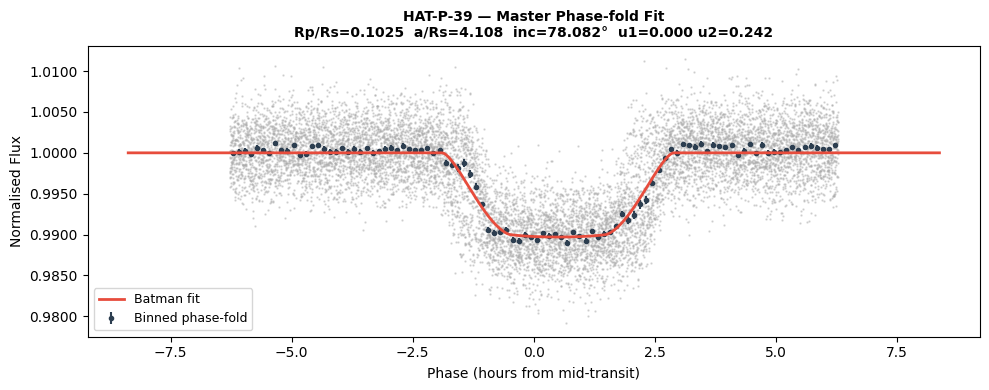


STATE["batman_params"] stored. Ready for Cell 7 export.


In [12]:
# Cell 6 — Master Batman Fit
# Fits Rp/Rs, a/Rs, inclination, limb darkening from the phase-folded light curve.
# Run once per planet. Re-run if you change STATE["t0"].

if not STATE:
    print('Run Cell 2 first.')
else:
    import batman
    from scipy.optimize import minimize
    from IPython.display import display as ipy_display

    time   = STATE['time']
    flux   = STATE['flux']
    period = STATE['period']
    t0     = STATE['t0']

    row      = df_priority[df_priority['System'] == STATE['name']].iloc[0]
    rp_init  = float(row['pl_ratror'])   if pd.notna(row.get('pl_ratror'))  else 0.1
    a_init   = float(row['pl_ratdor'])   if pd.notna(row.get('pl_ratdor'))  else 10.0
    inc_init = float(row['pl_orbincl'])  if pd.notna(row.get('pl_orbincl')) else 88.0
    ecc      = float(row['pl_orbeccen']) if pd.notna(row.get('pl_orbeccen')) and row['pl_orbeccen'] >= 0 else 0.0
    teff     = float(row['st_teff'])     if pd.notna(row.get('st_teff'))    else 5500.0

    ld_table = [(7000,0.20,0.20),(6000,0.33,0.25),(5000,0.44,0.25),(4000,0.55,0.22),(0,0.65,0.15)]
    u1_init, u2_init = next((u1,u2) for thr,u1,u2 in ld_table if teff >= thr)

    print(f'Initial guesses:')
    print(f'  Rp/Rs={rp_init:.4f}  a/Rs={a_init:.3f}  inc={inc_init:.3f}°')
    print(f'  u1={u1_init:.3f}  u2={u2_init:.3f}  ecc={ecc:.3f}')
    print(f'  t0(BTJD)={t0:.6f}  P={period:.6f}d')

    def batman_model(t_arr, t0_val, rp, a, inc, u1, u2):
        p = batman.TransitParams()
        p.t0 = t0_val; p.per = period; p.rp = abs(rp)
        p.a  = abs(a);  p.inc = inc;   p.ecc = ecc
        p.w  = 90.0;    p.u = [u1, u2]; p.limb_dark = 'quadratic'
        try:
            return batman.TransitModel(p, t_arr).light_curve(p)
        except:
            return np.ones_like(t_arr)

    # Phase-fold
    phase = ((time - t0) % period) / period
    phase = np.where(phase > 0.5, phase - 1, phase)

    half_dur_phase = (STATE['trandur'] / 24) / period
    in_transit     = np.abs(phase) <= half_dur_phase * 1.5
    t_fold  = phase[in_transit] * period
    fl_fold = np.array(flux[in_transit], dtype=float)

    def residuals(params):
        t0_off, rp, a, inc, u1, u2 = params
        model = batman_model(t_fold, t0_off, rp, a, inc, u1, u2)
        return np.sum((fl_fold - model)**2)

    x0     = [0.0, rp_init, a_init, inc_init, u1_init, u2_init]
    bounds = [(-0.05, 0.05),
              (rp_init*0.5, rp_init*2),
              (a_init*0.5,  a_init*2),
              (60.0, 90.0),
              (0.0, 1.0),
              (0.0, 1.0)]

    print('\nFitting master batman model...')
    result = minimize(residuals, x0, bounds=bounds, method='L-BFGS-B',
                      options={'maxiter': 2000, 'ftol': 1e-12})

    t0_off_fit, rp_fit, a_fit, inc_fit, u1_fit, u2_fit = result.x

    STATE['batman_params'] = {
        't0_offset': t0_off_fit,
        'rp': rp_fit, 'a': a_fit, 'inc': inc_fit,
        'u1': u1_fit, 'u2': u2_fit, 'ecc': ecc,
        'period': period,
    }

    print(f'\nFitted parameters:')
    print(f'  Rp/Rs = {rp_fit:.5f}   (init: {rp_init:.5f})')
    print(f'  a/Rs  = {a_fit:.4f}   (init: {a_init:.4f})')
    print(f'  inc   = {inc_fit:.4f}°  (init: {inc_init:.4f}°)')
    print(f'  u1    = {u1_fit:.4f}   u2 = {u2_fit:.4f}')
    print(f'  t0 offset = {t0_off_fit*24*60:+.2f} min')

    # Diagnostic phase-fold plot
    t_ph_plot = np.linspace(-half_dur_phase*2*period, half_dur_phase*2*period, 500)
    model_ph  = batman_model(t_ph_plot, t0_off_fit, rp_fit, a_fit, inc_fit, u1_fit, u2_fit)

    # Bin folded data — cast explicitly to float arrays to avoid matplotlib ndim bug
    n_bins = 100
    edges  = np.linspace(t_fold.min(), t_fold.max(), n_bins + 1)
    bc, bf, be = [], [], []
    for i in range(n_bins):
        m = (t_fold >= edges[i]) & (t_fold < edges[i+1])
        if m.sum() >= 2:
            bc.append(float(0.5*(edges[i]+edges[i+1])))
            bf.append(float(np.median(fl_fold[m])))
            be.append(float(np.std(fl_fold[m]) / np.sqrt(m.sum())))

    bc = np.array(bc, dtype=float)
    bf = np.array(bf, dtype=float)
    be = np.array(be, dtype=float)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_fold*24, fl_fold, '.', ms=1.5, color='#AAAAAA', alpha=0.4, rasterized=True)
    if len(bc) > 0:
        ax.errorbar(bc*24, bf, yerr=be, fmt='o', ms=3,
                    color='#2C3E50', label='Binned phase-fold', zorder=3)
    ax.plot(t_ph_plot*24, model_ph, color='#E74C3C', lw=2, label='Batman fit', zorder=4)
    ax.set_xlabel('Phase (hours from mid-transit)', fontsize=10)
    ax.set_ylabel('Normalised Flux', fontsize=10)
    ax.set_title(f'{STATE["name"]} — Master Phase-fold Fit\n'
                 f'Rp/Rs={rp_fit:.4f}  a/Rs={a_fit:.3f}  inc={inc_fit:.3f}°  '
                 f'u1={u1_fit:.3f} u2={u2_fit:.3f}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
    plt.tight_layout()
    ipy_display(fig)
    plt.close(fig)
    print('\nSTATE["batman_params"] stored. Ready for Cell 7 export.')

---
## Cell 7 — Export Single Transit
Set `EXPORT_SECTOR` and `EXPORT_TRANSIT_N`, then run.
Produces the 5 CSVs + 3 diagnostic images under `results/{planet}/s{sector}/t{n}/`.

In [ ]:
# Cell 7 — Export Single Transit
# 1. Set EXPORT_SECTOR and EXPORT_TRANSIT_N
# 2. Preview in Cell 5 first — if the red dashed line is off, set T0_FINE_TUNE_MIN
# 3. Run to export

EXPORT_SECTOR    = None   # e.g. 44  (None = first available)
EXPORT_TRANSIT_N = 1      # 1-based index within the sector
T0_FINE_TUNE_MIN = 0.0    # minutes — shift tc_fit left(-) or right(+) to align visually

if not STATE:
    print('Run Cell 2 first.')
elif 'batman_params' not in STATE:
    print('Run Cell 6 first to fit the master batman model.')
else:
    import os
    from scipy.optimize import minimize_scalar
    from IPython.display import display as ipy_display

    sector_lcs = STATE['sector_lcs']
    sectors    = sorted(sector_lcs.keys())
    sector     = EXPORT_SECTOR if EXPORT_SECTOR in sectors else sectors[0]
    bp         = STATE['batman_params']
    name       = STATE['name']
    period     = STATE['period']
    t0_ref     = STATE['t0'] + bp['t0_offset']
    trandur    = STATE['trandur']
    half_dur   = trandur / 24 / 2

    t, f = sector_lcs[sector]

    all_tc = predict_transit_times(period, t0_ref, t.min(), t.max())
    usable = [tc for tc in all_tc if np.sum(np.abs(t - tc) <= half_dur) >= 10]

    if not usable:
        print(f'No usable transits in Sector {sector}.')
    elif EXPORT_TRANSIT_N > len(usable):
        print(f'Only {len(usable)} usable transits in Sector {sector}. '
              f'Set EXPORT_TRANSIT_N to 1–{len(usable)}.')
    else:
        tc_nominal = usable[EXPORT_TRANSIT_N - 1]

        # Per-transit t0 fit
        in_mask = np.abs(t - tc_nominal) <= half_dur
        t_in = t[in_mask]; f_in = f[in_mask]

        def batman_fixed_shape(t_arr, tc):
            p = batman.TransitParams()
            p.t0 = tc; p.per = period; p.rp = bp['rp']
            p.a  = bp['a']; p.inc = bp['inc']; p.ecc = bp['ecc']
            p.w  = 90.0; p.u = [bp['u1'], bp['u2']]
            p.limb_dark = 'quadratic'
            try:
                return batman.TransitModel(p, t_arr).light_curve(p)
            except:
                return np.ones_like(t_arr)

        def cost(tc):
            return np.sum((f_in - batman_fixed_shape(t_in, tc))**2)

        result = minimize_scalar(cost,
                                 bounds=(tc_nominal - half_dur*0.5,
                                         tc_nominal + half_dur*0.5),
                                 method='bounded')

        # Apply manual fine-tune on top of the per-transit fit
        tc_fit = result.x + T0_FINE_TUNE_MIN / (24 * 60)

        # Extract windows: pre = T, in = T, post = T
        pre_mask  = (t >= tc_fit - 3*half_dur) & (t <  tc_fit - half_dur)
        in_mask2  = np.abs(t - tc_fit) <= half_dur
        post_mask = (t >  tc_fit + half_dur)   & (t <= tc_fit + 3*half_dur)

        t_pre  = t[pre_mask];  f_pre  = f[pre_mask]
        t_in2  = t[in_mask2];  f_in2  = f[in_mask2]
        t_post = t[post_mask]; f_post = f[post_mask]

        model_in = batman_fixed_shape(t_in2, tc_fit)
        residual = f_in2 - model_in

        def detrend(t_w, f_w):
            if len(t_w) < 2: return f_w
            c = np.polyfit(t_w - t_w.mean(), f_w, 1)
            return f_w - np.polyval(c, t_w - t_w.mean()) + 1.0

        f_pre_dt  = detrend(t_pre, f_pre)
        f_post_dt = detrend(t_post, f_post)
        n_pre, n_in, n_post = len(f_pre_dt), len(f_in2), len(f_post_dt)

        print(f'Transit: Sector {sector:02d}  #{EXPORT_TRANSIT_N}/{len(usable)}')
        print(f'  tc auto-fit={result.x:.5f}  fine-tune={T0_FINE_TUNE_MIN:+.2f} min')
        print(f'  tc final   ={tc_fit:.5f} BTJD')
        print(f'  Window T={trandur:.2f}h  |  Pre={n_pre}  In={n_in}  Post={n_post} pts')

        out_dir = os.path.join('results', name, f's{sector:03d}', f't{EXPORT_TRANSIT_N:03d}')
        os.makedirs(out_dir, exist_ok=True)

        def save_csv(filename, index_arr, values, col_name):
            pd.DataFrame({'index []': index_arr, col_name: values})\
              .to_csv(os.path.join(out_dir, filename), index=False)

        save_csv('pre.csv',         np.arange(1,n_pre+1),  f_pre_dt,  'flux []')
        save_csv('in_raw.csv',      np.arange(1,n_in+1),   f_in2,     'flux []')
        save_csv('in_model.csv',    np.arange(1,n_in+1),   model_in,  'flux []')
        save_csv('in_residual.csv', np.arange(1,n_in+1),   residual,  'flux residual []')
        save_csv('post.csv',        np.arange(1,n_post+1), f_post_dt, 'flux []')
        print(f'  CSVs → {out_dir}/')

        # Image 1: Overview
        wing = half_dur * 4
        ov_mask = np.abs(t - tc_fit) <= wing
        fig1, ax1 = plt.subplots(figsize=(12, 4))
        ax1.plot(t[ov_mask], f[ov_mask], '.', ms=2, color='#333333', alpha=0.7, rasterized=True)
        ax1.axvspan(tc_fit-3*half_dur, tc_fit-half_dur, alpha=0.15, color='#3498DB',
                    label=f'Pre-baseline (T={trandur:.2f}h)')
        ax1.axvspan(tc_fit-half_dur,   tc_fit+half_dur, alpha=0.20, color='#E74C3C',
                    label=f'Transit window (T={trandur:.2f}h)')
        ax1.axvspan(tc_fit+half_dur,   tc_fit+3*half_dur, alpha=0.15, color='#2ECC71',
                    label=f'Post-baseline (T={trandur:.2f}h)')
        ax1.axvline(tc_fit, color='#E74C3C', lw=1.0, ls='--', alpha=0.8)
        ax1.set_xlabel('BTJD (days)', fontsize=10); ax1.set_ylabel('Normalised Flux', fontsize=10)
        ax1.set_title(f'{name}  S{sector:02d}  T{EXPORT_TRANSIT_N} — Window Overview\n'
                      f'tc={tc_fit:.5f} BTJD  fine-tune={T0_FINE_TUNE_MIN:+.2f} min  '
                      f'pre={n_pre}  in={n_in}  post={n_post} pts',
                      fontsize=10, fontweight='bold')
        ax1.legend(fontsize=8); ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
        plt.tight_layout()
        fig1.savefig(os.path.join(out_dir,'overview.png'), dpi=130, bbox_inches='tight')
        ipy_display(fig1); plt.close(fig1)

        # Image 2: Batman fit
        t_ml = np.linspace(t_in2.min(), t_in2.max(), 500)
        fig2, ax2 = plt.subplots(figsize=(10, 4))
        ax2.plot(t_in2, f_in2, 'o', ms=4, color='#2C3E50', alpha=0.8, label='Observed', zorder=3)
        ax2.plot(t_ml, batman_fixed_shape(t_ml, tc_fit), color='#E74C3C', lw=2, label='Batman model', zorder=4)
        ax2.axvline(tc_fit, color='#E74C3C', lw=0.8, ls='--', alpha=0.6)
        ax2.set_xlabel('BTJD (days)', fontsize=10); ax2.set_ylabel('Normalised Flux', fontsize=10)
        ax2.set_title(f'{name}  S{sector:02d}  T{EXPORT_TRANSIT_N} — Observed vs Batman Model\n'
                      f'Rp/Rs={bp["rp"]:.4f}  a/Rs={bp["a"]:.3f}  inc={bp["inc"]:.3f}°  tc={tc_fit:.5f}',
                      fontsize=10, fontweight='bold')
        ax2.legend(fontsize=9); ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.4f'))
        plt.tight_layout()
        fig2.savefig(os.path.join(out_dir,'batman_fit.png'), dpi=130, bbox_inches='tight')
        ipy_display(fig2); plt.close(fig2)

        # Image 3: Residuals
        fig3, ax3 = plt.subplots(figsize=(10, 3))
        ax3.plot(t_in2, residual, 'o', ms=3, color='#8E44AD', alpha=0.8)
        ax3.axhline(0, color='grey', lw=1.0, ls='--')
        ax3.fill_between(t_in2, residual, 0, alpha=0.15, color='#8E44AD')
        ax3.set_xlabel('BTJD (days)', fontsize=10); ax3.set_ylabel('Flux residual', fontsize=10)
        ax3.set_title(f'{name}  S{sector:02d}  T{EXPORT_TRANSIT_N} — Residuals  (RMS={np.std(residual):.5f})',
                      fontsize=10, fontweight='bold')
        ax3.yaxis.set_major_formatter(plt.FormatStrFormatter('%.5f'))
        plt.tight_layout()
        fig3.savefig(os.path.join(out_dir,'residuals.png'), dpi=130, bbox_inches='tight')
        ipy_display(fig3); plt.close(fig3)

        print(f'  Images → {out_dir}/')
        print(f'  Files: {sorted(os.listdir(out_dir))}')